# EfficientNet-B0 + CBAM — Leaf Classification

Pretrained EfficientNet-B0 + CBAM fine-tuned on `data/train|val|test/` (grouped split, produced by
`01_preprocessing.ipynb`), with class-weighted loss from `data/class_weights.json`.

**This notebook is unexecuted — run all cells yourself to train.**


In [1]:
import os, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

# ── Paths ──────────────────────────────────────
DATA_DIR   = Path("data")
OUTPUT_DIR = Path("efficientnet_b0_cbam_results")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Hyperparameters ─────────────────────────────
CLASSES     = sorted(d.name for d in (DATA_DIR / "train").iterdir() if d.is_dir())
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 50
PATIENCE    = 5
MIN_EPOCHS_BEFORE_STOP = 15
LR          = 1e-4       # lower than the from-scratch CNN's 1e-3 — this is fine-tuning pretrained weights
SEED        = 42
NUM_WORKERS = 2

# Fixed categorical color per class (never cycled), reused across every chart in this notebook
CLASS_COLORS = dict(zip(CLASSES, ["#2a78d6", "#008300", "#e87ba4", "#eda100",
                                   "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"]))

if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available. Check nvidia-smi, then re-run.")

DEVICE = torch.device("cuda")
torch.backends.cudnn.benchmark = True
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

print(f"Classes ({NUM_CLASSES}): {CLASSES}")
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


/home/nathiskar/Documents/Task04/.venv/lib/python3.10/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


Classes (8): ['Apple', 'Berry', 'Fig', 'Guava', 'Orange', 'Palm', 'Persimmon', 'Tomato']
GPU : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.0 GB


## Data pipeline

In [2]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=25, border_mode=0, fill=0, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.4),
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0), p=0.5),
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])


class LeafDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None):
        self.transform = transform
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.samples = []
        for c in classes:
            for p in sorted(Path(root_dir, c).glob("*.jpg")):
                self.samples.append((str(p), self.class_to_idx[c]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = np.array(Image.open(path).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, label


train_ds = LeafDataset(DATA_DIR / "train", CLASSES, transform=train_transform)
val_ds   = LeafDataset(DATA_DIR / "val",   CLASSES, transform=eval_transform)
test_ds  = LeafDataset(DATA_DIR / "test",  CLASSES, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

print(f"train: {len(train_ds)}  val: {len(val_ds)}  test: {len(test_ds)}")


train: 2510  val: 535  test: 543


## Class weights\nLoaded from `data/class_weights.json` (computed on the train split only).

In [3]:
with open(DATA_DIR / "class_weights.json") as f:
    class_weights = json.load(f)

class_weights_tensor = torch.tensor([class_weights[c] for c in CLASSES], dtype=torch.float32).to(DEVICE)
for c, w in class_weights.items():
    print(f"  {c:12s}: {w:.3f}")


  Apple       : 0.860
  Berry       : 1.313
  Fig         : 0.899
  Guava       : 0.857
  Orange      : 0.832
  Palm        : 0.957
  Persimmon   : 0.839
  Tomato      : 2.801


## Model: EfficientNet-B0 + CBAM (ImageNet pretrained backbone)\n`torchvision.models.efficientnet_b0` backbone with a CBAM (channel + spatial attention) block inserted after the final conv features (1280 channels), before global pooling. Classifier head replaced for 8 classes, fully fine-tuned (CBAM trained from scratch).

In [4]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    """Convolutional Block Attention Module (Woo et al., 2018) — channel then spatial attention."""
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x


class EfficientNetB0_CBAM(nn.Module):
    """EfficientNet-B0 backbone with a CBAM block inserted after the conv features,
    before global pooling, so attention is applied to the final 1280-channel feature map."""
    def __init__(self, num_classes, p_drop=0.2):
        super().__init__()
        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.features  = backbone.features
        self.cbam      = CBAM(channels=1280)
        self.avgpool   = backbone.avgpool
        self.classifier = nn.Sequential(
            nn.Dropout(p=p_drop, inplace=True),
            nn.Linear(1280, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


model     = EfficientNetB0_CBAM(NUM_CLASSES, p_drop=0.2).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LR)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"EfficientNet-B0 + CBAM — trainable parameters: {total_params:,}")


EfficientNet-B0 + CBAM — trainable parameters: 4,222,694


## Training (AMP + early stopping, best model saved on val loss)

In [5]:
BEST_MODEL_PATH = OUTPUT_DIR / "best_efficientnet_b0_cbam.pth"

scaler_amp        = torch.amp.GradScaler("cuda")
best_val_loss     = float("inf")
epochs_no_improve = 0
train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    run_loss, run_correct, run_total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()

        with torch.no_grad():
            preds = outputs.argmax(1)

        run_loss    += loss.item() * inputs.size(0)
        run_correct += (preds == labels).sum().item()
        run_total   += inputs.size(0)

    train_loss = run_loss / run_total
    train_acc  = run_correct / run_total
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
            inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda"):
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
            val_loss    += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += inputs.size(0)

    val_loss /= val_total
    val_acc   = val_correct / val_total
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f"[Epoch {epoch:02d}]  "
          f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    # ── Early stopping ──
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Best model saved  (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epoch < MIN_EPOCHS_BEFORE_STOP:
            print(f"  -> No improvement for {epochs_no_improve}/{PATIENCE}, "
                  f"but continuing until at least epoch {MIN_EPOCHS_BEFORE_STOP}.")
        elif epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} after {epochs_no_improve} epochs without improvement.")
            break

print(f"\nTraining complete. Best model -> {BEST_MODEL_PATH}")


Epoch 1/50 [Train]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/17 [00:00<?, ?it/s]

[Epoch 01]  Train Acc: 0.8040  Val Acc: 0.9757  Train Loss: 1.2206  Val Loss: 0.1252
  -> Best model saved  (val_loss=0.1252)


Epoch 2/50 [Train]:   0%|          | 0/79 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x748dbc7e5b40>
Traceback (most recent call last):
  File "/home/nathiskar/Documents/Task04/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1704, in __del__
    self._shutdown_workers()
  File "/home/nathiskar/Documents/Task04/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1673, in _shutdown_workers
    if w.is_alive():
  File "/home/nathiskar/.pyenv/versions/3.10.14/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x748dbc7e5b40>assert self._parent_pid == os.getpid(), 'can only test a child process'

Traceback (most recent call last):
  File "/home/nathiskar/Documents/Task04/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1704, in __del__
AssertionErrorException ignored in:     : self._shutdown_workers()Exception ignored in: <function _MultiPro

...

Epoch 19/50 [Val]:   0%|          | 0/17 [00:00<?, ?it/s]

[Epoch 19]  Train Acc: 0.9976  Val Acc: 1.0000  Train Loss: 0.0082  Val Loss: 0.0004


Epoch 20/50 [Train]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20/50 [Val]:   0%|          | 0/17 [00:00<?, ?it/s]

[Epoch 20]  Train Acc: 0.9988  Val Acc: 1.0000  Train Loss: 0.0077  Val Loss: 0.0003
Early stopping at epoch 20 after 5 epochs without improvement.

Training complete. Best model -> efficientnet_b0_cbam_results/best_efficientnet_b0_cbam.pth


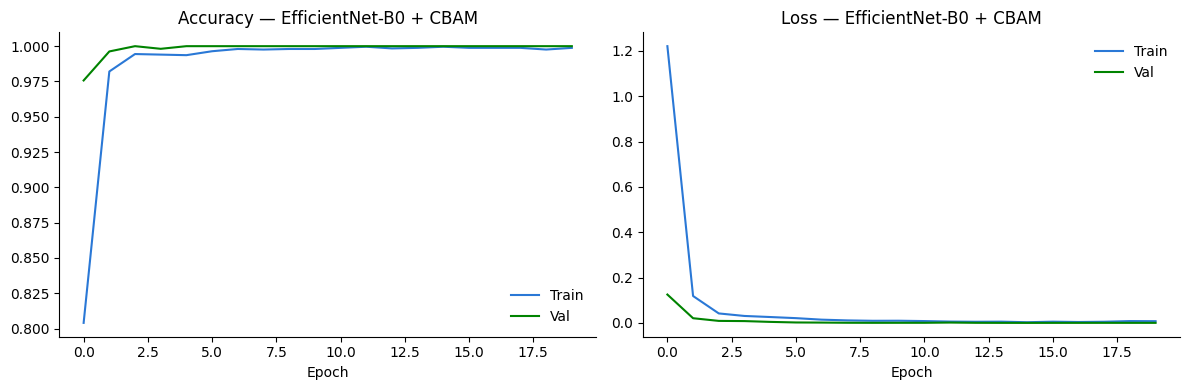

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_acc_hist, label="Train", color="#2a78d6")
axes[0].plot(val_acc_hist,   label="Val",   color="#008300")
axes[0].set_title("Accuracy — EfficientNet-B0 + CBAM"); axes[0].set_xlabel("Epoch"); axes[0].legend(frameon=False)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(train_loss_hist, label="Train", color="#2a78d6")
axes[1].plot(val_loss_hist,   label="Val",   color="#008300")
axes[1].set_title("Loss — EfficientNet-B0 + CBAM"); axes[1].set_xlabel("Epoch"); axes[1].legend(frameon=False)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150)
plt.show()


## Test evaluation\nLoad the best (lowest val-loss) checkpoint and evaluate once, on the held-out test split.

In [7]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference", leave=False):
        inputs = inputs.to(DEVICE)
        with torch.amp.autocast("cuda"):
            outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).float().cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
test_acc   = (all_preds == all_labels).mean()
print(f"Test Accuracy (EfficientNet-B0 + CBAM): {test_acc * 100:.2f}%")
print(f"Correct: {(all_preds == all_labels).sum()} / {len(all_labels)}")


Inference:   0%|          | 0/17 [00:00<?, ?it/s]

Test Accuracy (EfficientNet-B0 + CBAM): 100.00%
Correct: 543 / 543


### Confusion matrix & classification report

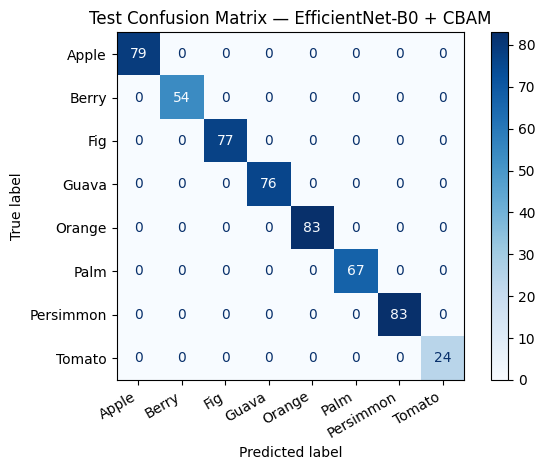

              precision    recall  f1-score   support

       Apple     1.0000    1.0000    1.0000        79
       Berry     1.0000    1.0000    1.0000        54
         Fig     1.0000    1.0000    1.0000        77
       Guava     1.0000    1.0000    1.0000        76
      Orange     1.0000    1.0000    1.0000        83
        Palm     1.0000    1.0000    1.0000        67
   Persimmon     1.0000    1.0000    1.0000        83
      Tomato     1.0000    1.0000    1.0000        24

    accuracy                         1.0000       543
   macro avg     1.0000    1.0000    1.0000       543
weighted avg     1.0000    1.0000    1.0000       543



In [8]:
cm   = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap="Blues", values_format="d")
plt.title("Test Confusion Matrix — EfficientNet-B0 + CBAM")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

report_txt = classification_report(all_labels, all_preds, target_names=CLASSES, digits=4)
print(report_txt)
with open(OUTPUT_DIR / "classification_report.txt", "w") as f:
    f.write(report_txt)
pd.DataFrame(
    classification_report(all_labels, all_preds, target_names=CLASSES, output_dict=True, digits=4)
).transpose().to_csv(OUTPUT_DIR / "classification_report.csv")


### Per-class precision / recall / F1

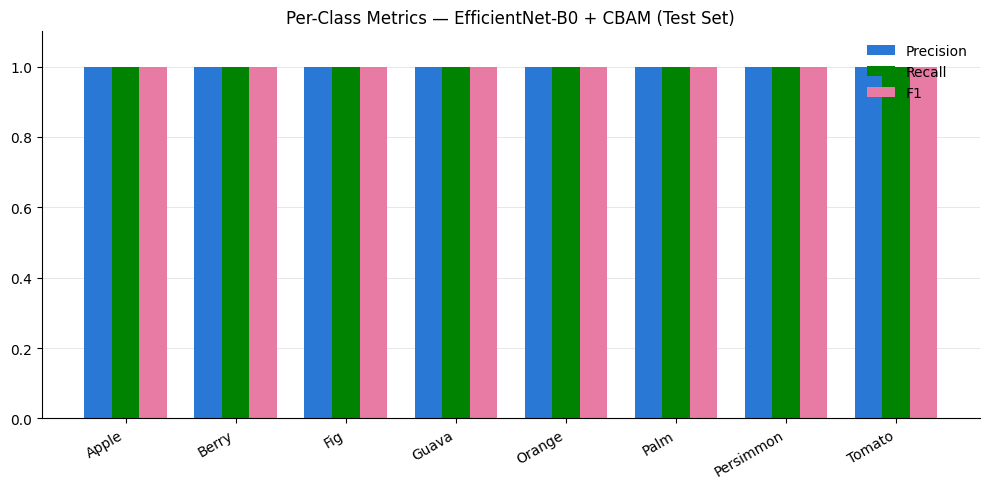

In [9]:
precision = precision_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
recall    = recall_score(all_labels,    all_preds, average=None, labels=range(NUM_CLASSES))
f1        = f1_score(all_labels,        all_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, precision, w, label="Precision", color="#2a78d6")
ax.bar(x,     recall,    w, label="Recall",    color="#008300")
ax.bar(x + w, f1,        w, label="F1",        color="#e87ba4")
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=30, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("Per-Class Metrics — EfficientNet-B0 + CBAM (Test Set)")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linewidth=0.5, color="#dddddd", zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_class_metrics.png", dpi=150)
plt.show()

pd.DataFrame({
    "Sample":     range(len(all_labels)),
    "True Label": [CLASSES[i] for i in all_labels],
    "Pred Label": [CLASSES[i] for i in all_preds],
    "Correct":    (all_preds == all_labels).astype(int)
}).to_csv(OUTPUT_DIR / "predictions.csv", index=False)


### ROC curve (one-vs-rest)

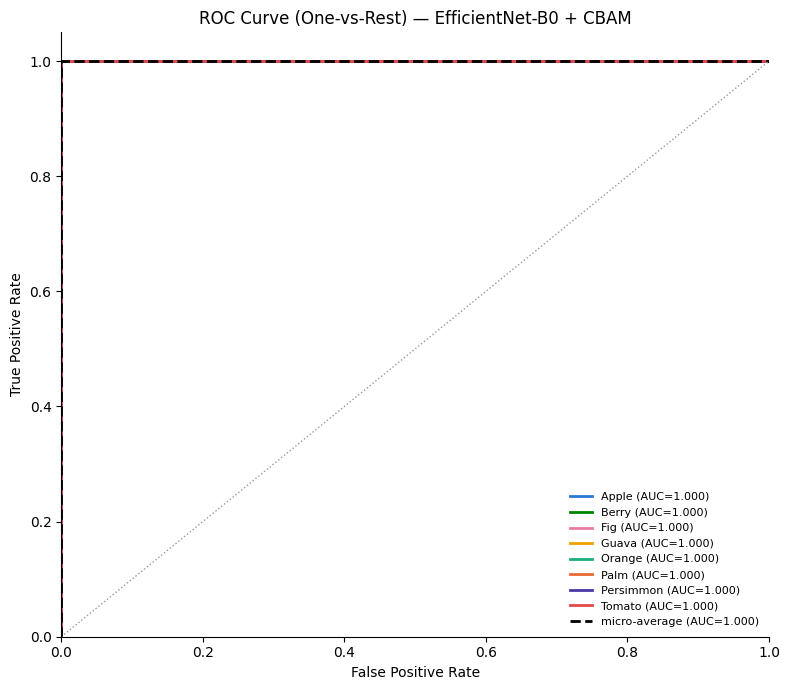

Per-class AUC:
  Apple       : 1.0000
  Berry       : 1.0000
  Fig         : 1.0000
  Guava       : 1.0000
  Orange      : 1.0000
  Palm        : 1.0000
  Persimmon   : 1.0000
  Tomato      : 1.0000
  micro-avg   : 1.0000


In [10]:
y_true_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

fig, ax = plt.subplots(figsize=(8, 7))
for i, cls in enumerate(CLASSES):
    ax.plot(fpr[i], tpr[i], color=CLASS_COLORS[cls], lw=2, label=f"{cls} (AUC={roc_auc[i]:.3f})")
ax.plot(fpr["micro"], tpr["micro"], color="black", lw=2, linestyle="--",
        label=f"micro-average (AUC={roc_auc['micro']:.3f})")
ax.plot([0, 1], [0, 1], color="#999999", lw=1, linestyle=":")
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve (One-vs-Rest) — EfficientNet-B0 + CBAM")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right", fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve.png", dpi=150)
plt.show()

print("Per-class AUC:")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:12s}: {roc_auc[i]:.4f}")
print(f"  {'micro-avg':12s}: {roc_auc['micro']:.4f}")


### Precision-Recall curve

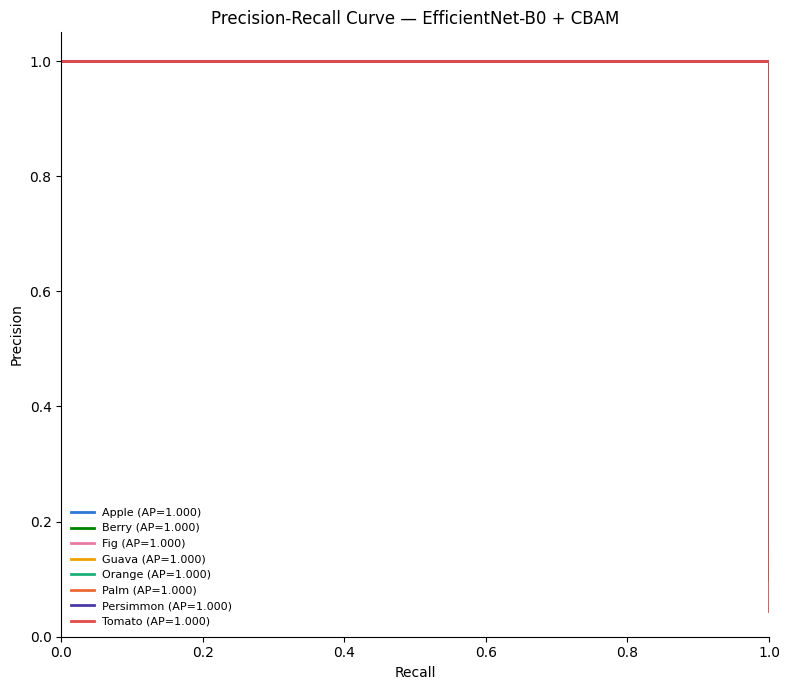

Per-class Average Precision:
  Apple       : 1.0000
  Berry       : 1.0000
  Fig         : 1.0000
  Guava       : 1.0000
  Orange      : 1.0000
  Palm        : 1.0000
  Persimmon   : 1.0000
  Tomato      : 1.0000


In [11]:
precision_d, recall_d, ap = {}, {}, {}
for i in range(NUM_CLASSES):
    precision_d[i], recall_d[i], _ = precision_recall_curve(y_true_bin[:, i], all_probs[:, i])
    ap[i] = average_precision_score(y_true_bin[:, i], all_probs[:, i])

fig, ax = plt.subplots(figsize=(8, 7))
for i, cls in enumerate(CLASSES):
    ax.plot(recall_d[i], precision_d[i], color=CLASS_COLORS[cls], lw=2, label=f"{cls} (AP={ap[i]:.3f})")
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — EfficientNet-B0 + CBAM")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower left", fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pr_curve.png", dpi=150)
plt.show()

print("Per-class Average Precision:")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:12s}: {ap[i]:.4f}")


## Feature / embedding extraction\nPenultimate-layer feature vectors (the input to the final classification layer), saved per split for a future mRMR + SVM / hybrid ML stage. Uses a forward hook so it works generically regardless of the classifier head's exact shape.

In [12]:
def get_final_linear(module_holder, attr_name="classifier"):
    """Return the actual nn.Linear submodule that produces the class logits,
    whether `classifier` is a bare Linear or a Sequential ending in one."""
    module = getattr(module_holder, attr_name)
    if isinstance(module, nn.Linear):
        return module
    elif isinstance(module, nn.Sequential):
        for layer in reversed(module):
            if isinstance(layer, nn.Linear):
                return layer
    raise TypeError(f"No Linear layer found in {attr_name}")


final_linear   = get_final_linear(model, "classifier")
embedding_dim  = final_linear.in_features
print(f"Embedding dimension (input to final Linear): {embedding_dim}")

_captured = {}

def _capture_hook(module, inputs, output):
    _captured["embedding"] = inputs[0].detach()

hook_handle = final_linear.register_forward_hook(_capture_hook)


@torch.no_grad()
def extract_embeddings(loader):
    model.eval()
    embs, labels = [], []
    for inputs, lbls in tqdm(loader, desc="Extracting embeddings", leave=False):
        inputs = inputs.to(DEVICE)
        with torch.amp.autocast("cuda"):
            _ = model(inputs)
        embs.append(_captured["embedding"].float().cpu().numpy())
        labels.append(lbls.numpy())
    return np.concatenate(embs), np.concatenate(labels)


# Deterministic (non-augmented) view of the train split, so features are stable/reproducible
# — unlike train_loader, which applies random augmentation for the training step above.
train_eval_ds      = LeafDataset(DATA_DIR / "train", CLASSES, transform=eval_transform)
train_embed_loader = DataLoader(train_eval_ds, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=NUM_WORKERS, pin_memory=True)

train_embs, train_y = extract_embeddings(train_embed_loader)
val_embs,   val_y   = extract_embeddings(val_loader)
test_embs,  test_y  = extract_embeddings(test_loader)

hook_handle.remove()

np.save(OUTPUT_DIR / "train_embs.npy", train_embs)
np.save(OUTPUT_DIR / "val_embs.npy",   val_embs)
np.save(OUTPUT_DIR / "test_embs.npy",  test_embs)
np.save(OUTPUT_DIR / "train_y.npy",    train_y)
np.save(OUTPUT_DIR / "val_y.npy",      val_y)
np.save(OUTPUT_DIR / "test_y.npy",     test_y)

print(f"train_embs: {train_embs.shape}  val_embs: {val_embs.shape}  test_embs: {test_embs.shape}")
print(f"Saved to {OUTPUT_DIR.resolve()}")


Embedding dimension (input to final Linear): 1280


Extracting embeddings:   0%|          | 0/79 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/17 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/17 [00:00<?, ?it/s]

train_embs: (2510, 1280)  val_embs: (535, 1280)  test_embs: (543, 1280)
Saved to /home/nathiskar/Documents/Task04/efficientnet_b0_cbam_results


## Summary

Artifacts saved to `efficientnet_b0_cbam_results/`:
- `best_efficientnet_b0_cbam.pth` — best checkpoint (lowest val loss)
- `training_curves.png` — train/val accuracy & loss over epochs
- `confusion_matrix.png`, `classification_report.{txt,csv}`, `per_class_metrics.png`, `predictions.csv`
- `roc_curve.png` — one-vs-rest ROC with per-class + micro-average AUC
- `pr_curve.png` — per-class precision-recall curves with average precision
- `train_embs.npy` / `val_embs.npy` / `test_embs.npy` (+ matching `*_y.npy` labels) — penultimate-layer
  features per split (dimension printed at extraction time), for a future mRMR + SVM (or other ML) hybrid
  stage, same pattern as the FYP CNN6+mRMR+SVM pipeline
